# Sistema de Visao Computacional para Seguranca do Trabalho

### Deteccao de EPIs em canteiros de obras com YOLOv8 + ByteTrack

Notebook da atividade de sistematizacao da disciplina de **Visao Computacional e
Reconhecimento de Padroes**.

**Pipeline:** preparacao do ambiente -> dataset e EDA -> fine-tuning do detector ->
curvas de treino -> avaliacao no teste -> inspecao qualitativa -> inferencia em video.

> Execute as celulas na ordem. Algumas dependem de variaveis definidas nas anteriores.

## 1. Preparacao do ambiente

Instalacao das dependencias e verificacao da GPU. O notebook foi executado no
Google Colab com aceleracao por GPU (Tesla T4).

> No menu do Colab: **Ambiente de execucao -> Alterar o tipo de ambiente de execucao -> GPU**.

In [ ]:
#@title 1️⃣ Preparação do Ambiente e Dependências
!pip install -q ultralytics supervision roboflow opencv-python matplotlib seaborn

import torch
import cv2
import os
import yaml
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import supervision as sv
from ultralytics import YOLO

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch: {torch.__version__} | Dispositivo: {device}")
print("GPU ativada e dependências instaladas com sucesso!" if device=="cuda" else "Ative a GPU no menu do Colab!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 385.0/385.0 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 4.3 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settin

## 2. Dataset e analise exploratoria

O dataset utilizado e o **Construction Site Safety Image Dataset** (Roboflow),
obtido via `kagglehub`. Ele traz 10 classes anotadas no formato YOLO.

Esta celula faz o download, copia os dados para um diretorio com permissao de
escrita, gera dinamicamente o `data.yaml` e plota a distribuicao de classes no
conjunto de treino.

**Classes:** Capacete, Mascara, Sem Capacete, Sem Mascara, Sem Colete, Pessoa,
Cone de Sinalizacao, Colete Refletor, Maquinaria, Veiculo.

Baixando o dataset via Kagglehub...
Using Colab cache for faster access to the 'construction-site-safety-image-dataset-roboflow' dataset.
Download concluído em: /kaggle/input/construction-site-safety-image-dataset-roboflow
Dataset preparado no ambiente: /content/dataset
Arquivo 'data.yaml' criado com sucesso em: /content/data.yaml
Classes do Dataset: ['Capacete', 'Máscara', 'Sem Capacete', 'Sem Máscara', 'Sem Colete', 'Pessoa', 'Cone de Sinalização', 'Colete Refletor', 'Maquinaria', 'Veículo']


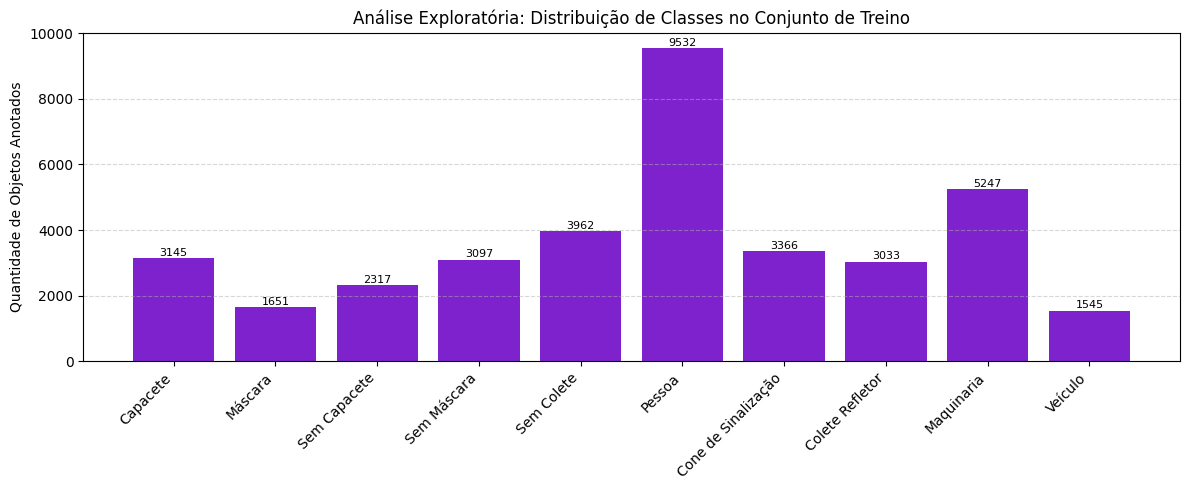

In [ ]:
#@title Download Automático do Dataset e Análise Exploratória (Fase 1 - Sem API Key)
!pip install -q kagglehub

import shutil
import yaml
import kagglehub

print("Baixando o dataset via Kagglehub...")

# 1. Download do dataset
download_path = kagglehub.dataset_download("snehilsanyal/construction-site-safety-image-dataset-roboflow")
print(f"Download concluído em: {download_path}")

# 2. Localiza a pasta raiz que contém os diretórios 'train' e 'valid'/'val'
base_download_dir = download_path
for root, dirs, files in os.walk(download_path):
    if 'train' in dirs and ('valid' in dirs or 'val' in dirs):
        base_download_dir = root
        break

# 3. Copia o dataset para o diretório local do Colab (/content/dataset) para garantir permissão de escrita
DATASET_DIR = "/content/dataset"
if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

shutil.copytree(base_download_dir, DATASET_DIR)
print(f"Dataset preparado no ambiente: {DATASET_DIR}")

# 4. Define os caminhos das pastas de treino, validação e teste
train_img_dir = os.path.join(DATASET_DIR, 'train', 'images')
val_img_dir = os.path.join(DATASET_DIR, 'valid' if os.path.exists(os.path.join(DATASET_DIR, 'valid')) else 'val', 'images')
test_img_dir = os.path.join(DATASET_DIR, 'test', 'images') if os.path.exists(os.path.join(DATASET_DIR, 'test')) else val_img_dir

# 5. Lista oficial das 10 classes do Roboflow 'construction-site-safety'
# Lista traduzida
classes = [
    'Capacete', 'Máscara', 'Sem Capacete', 'Sem Máscara', 'Sem Colete',
    'Pessoa', 'Cone de Sinalização', 'Colete Refletor', 'Maquinaria', 'Veículo'
]

# 6. Gerar dinamicamente o arquivo 'data.yaml'
DATASET_YAML = "/content/data.yaml"
data_cfg = {
    'path': DATASET_DIR,
    'train': train_img_dir,
    'val': val_img_dir,
    'test': test_img_dir,
    'nc': len(classes),
    'names': classes
}

with open(DATASET_YAML, 'w') as f:
    yaml.dump(data_cfg, f, default_flow_style=False)

print(f"Arquivo 'data.yaml' criado com sucesso em: {DATASET_YAML}")
print("Classes do Dataset:", classes)

# 7. Contagem e Análise Exploratória dos Rótulos no Conjunto de Treino (EDA)
def analisar_rotulos(pasta_labels):
    contagem = {i: 0 for i in range(len(classes))}
    if not os.path.exists(pasta_labels):
        print(f"Diretório de rótulos não encontrado: {pasta_labels}")
        return contagem

    for label_file in os.listdir(pasta_labels):
        if label_file.endswith('.txt'):
            with open(os.path.join(pasta_labels, label_file), 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if parts:
                        try:
                            cls_id = int(parts[0])
                            if cls_id in contagem:
                                contagem[cls_id] += 1
                        except ValueError:
                            continue
    return contagem

train_labels_dir = os.path.join(DATASET_DIR, "train", "labels")
contagem_train = analisar_rotulos(train_labels_dir)

# 8. Visualização Gráfica da Distribuição de Classes
plt.figure(figsize=(12, 5))
barras = plt.bar([classes[i] for i in contagem_train.keys()], contagem_train.values(), color='#7e22ce')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Quantidade de Objetos Anotados")
plt.title("Análise Exploratória: Distribuição de Classes no Conjunto de Treino")
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in barras:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 3. Fine-tuning do detector (YOLOv8m)

Treinamento a partir dos pesos pre-treinados no COCO.

| Hiperparametro | Valor |
| --- | --- |
| Modelo base | `yolov8m.pt` |
| Epocas | 40 |
| Tamanho da imagem | 640 |
| Batch size | 16 |
| Seed | 42 |
| Hardware | Tesla T4 (Colab) |

O treino completo levou aproximadamente **55 minutos**.

In [ ]:
#@title Fine-Tuning do Modelo YOLO (YOLOv8m)
# Hiperparâmetros
EPOCHS = 40
IMG_SIZE = 640
BATCH_SIZE = 16
SEED = 42

# Carregar modelo pré-treinado no COCO
model = YOLO("yolov8m.pt") # Pode usar "yolov8m-seg.pt" se o dataset fornecer polígonos de segmentação

print("Iniciando o Fine-Tuning")
results = model.train(
    data=DATASET_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    seed=SEED,
    workers=4,
    device=0 if device == "cuda" else "cpu",
    project="vcrp_seguranca",
    name="yolo_epi_detection",
    exist_ok=True
)

print("Treinamento concluído!")

Iniciando o Fine-Tuning
Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_epi_detection, nbs=64, nms=No

## 4. Curvas de treinamento

Localiza automaticamente o `results.png` gerado pelo Ultralytics. Caso o PNG nao
exista, o grafico e reconstruido a partir do `results.csv`, exibindo as perdas de
treino/validacao e as metricas de precisao, recall e mAP ao longo das epocas.

In [ ]:
#@title Localizador Automático e Visualizador do Gráfico de Treino
import glob
import pandas as pd
from IPython.display import Image, display

# Busca automática recursiva por 'results.png' e 'results.csv'
png_files = glob.glob("**/results.png", recursive=True)
csv_files = glob.glob("**/results.csv", recursive=True)

if png_files:
    png_path = png_files[-1] # Pega a execução mais recente
    print(f"Imagem do gráfico encontrada em: {png_path}")
    display(Image(filename=png_path))

elif csv_files:
    csv_path = csv_files[-1]
    print(f"PNG não encontrado. Gerando gráfico direto do CSV em: {csv_path}")

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()

    metrics_grid = [
        ["train/box_loss", "train/cls_loss", "train/dfl_loss", "metrics/precision(B)", "metrics/recall(B)"],
        ["val/box_loss",   "val/cls_loss",   "val/dfl_loss",   "metrics/mAP50(B)",     "metrics/mAP50-95(B)"]
    ]

    fig, axs = plt.subplots(2, 5, figsize=(18, 7))

    for row in range(2):
        for col in range(5):
            metric_name = metrics_grid[row][col]
            ax = axs[row, col]

            if metric_name in df.columns:
                epochs = df['epoch']
                values = df[metric_name]

                # Plot da linha principal (results) e da média móvel (smooth)
                ax.plot(epochs, values, 'o-', color='#1f77b4', markersize=3, linewidth=1.2, label='results')
                smooth_values = values.ewm(span=5).mean()
                ax.plot(epochs, smooth_values, ':', color='#ff7f0e', linewidth=1.8, label='smooth')

                ax.set_title(metric_name, fontsize=10, fontweight='bold')
                ax.grid(False)

                if row == 0 and col == 1:
                    ax.legend(loc='upper right', fontsize=9)

    plt.tight_layout()
    plt.show()

else:
    print("Nenhum resultado de treinamento foi encontrado no ambiente.")
    print("Verifique se a célula 'model.train()' finalizou todas as épocas sem interrupção.")

## 5. Avaliacao no conjunto de teste

Metricas calculadas sobre o split de **teste**, com dados que nao participaram do
treinamento.

Resultados obtidos na execucao de referencia:

| Metrica | Valor |
| --- | --- |
| mAP@0.5 | 0.853 |
| mAP@0.5:0.95 | 0.575 |
| Precisao media | 0.923 |
| Recall medio | 0.796 |

In [ ]:
#@title Métricas Oficiais no Conjunto de Teste (mAP, IoU, Precisão, Recall)
import glob

# Localizar automaticamente o ficheiro de pesos best.pt mais recente
weights_files = glob.glob("**/weights/best.pt", recursive=True)

if weights_files:
    best_weights_path = weights_files[-1]
    print(f"Pesos do modelo encontrado: {best_weights_path}")

    # Carregar o melhor modelo
    best_model = YOLO(best_weights_path)

    # avaliação no conjunto de TESTE
    metrics = best_model.val(data=DATASET_YAML, split="test")

    print("\n==================================================")
    print("RESULTADOS NO CONJUNTO DE TESTE (COM DADOS QUE NAO PARTICIPARAM DO TRINAMENTO)")
    print("==================================================")
    print(f" • mAP@0.5       : {metrics.box.map50:.4f}")
    print(f" • mAP@0.5:0.95  : {metrics.box.map:.4f}")
    print(f" • Precisão Média: {metrics.box.mp:.4f}")
    print(f" • Recall Médio  : {metrics.box.mr:.4f}")
else:
    print("Ficheiro 'best.pt' não encontrado. Verifique se o treinamento foi concluído.")

## 6. Inspecao qualitativa

Analise visual das deteccoes em amostras do conjunto de teste, usando os
anotadores da biblioteca `supervision`. Serve para identificar falsos positivos e
falsos negativos que as metricas agregadas nao revelam.

In [ ]:
#@title Inspeção Qualitativa de Detecções no Conjunto de Teste

# 1. Caminho para as imagens de teste
DATASET_DIR = "/content/dataset"
test_images_path = os.path.join(DATASET_DIR, "test", "images")

# Procura imagens de teste (.jpg, .jpeg, .png)
test_images = glob.glob(os.path.join(test_images_path, "*.[jJ][pP]*[gG]"))

if not test_images:
    # Busca alternativa se a pasta 'test' não existir no local exato
    test_images = glob.glob(os.path.join(DATASET_DIR, "**", "*.[jJ][pP]*[gG]"), recursive=True)

test_images = test_images[:4] # Seleciona as primeiras 4 imagens

# 2. Localizar e carregar os melhores pesos (best.pt)
weights_files = glob.glob("**/weights/best.pt", recursive=True)
best_weights_path = weights_files[-1] if weights_files else "yolov8m.pt"
best_model = YOLO(best_weights_path)

nomes_pt = {
    0: 'Capacete',
    1: 'Máscara',
    2: 'Sem Capacete',
    3: 'Sem Máscara',
    4: 'Sem Colete',
    5: 'Pessoa',
    6: 'Cone de Sinalização',
    7: 'Colete Refletor',
    8: 'Maquinaria',
    9: 'Veículo'
}

# 3. Sobrescrever os nomes no modelo
best_model.model.names = nomes_pt

# 4. Anotadores do Supervision
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for i, img_path in enumerate(test_images):
    image = cv2.imread(img_path)
    res = best_model(image)[0]
    detections = sv.Detections.from_ultralytics(res)

    labels = [
        f"{res.names[class_id]} {conf:.2f}"
        for conf, class_id in zip(detections.confidence, detections.class_id)
    ]

    annotated = box_annotator.annotate(scene=image.copy(), detections=detections)
    annotated = label_annotator.annotate(scene=annotated, detections=detections, labels=labels)

    axs[i].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axs[i].set_title(f"Amostra de Teste {i+1}", fontsize=10)
    axs[i].axis("off")

plt.tight_layout()
plt.show()

## 7. Inferencia em video com rastreamento (ByteTrack)

Etapa final: aplicacao do modelo treinado a um video de canteiro de obras,
combinada com o rastreador **ByteTrack** para manter a identidade temporal de
cada objeto entre frames.

O download tenta primeiro o YouTube via `yt-dlp`; se o IP do Colab for bloqueado,
cai automaticamente para um video de backup hospedado no GitHub.

A saida e gravada em `video_resultado_bytetrack.mp4`.

In [ ]:
#@title 6️⃣ Download do Vídeo e Rastreamento Temporal com ByteTrack (Fase Bônus)
!pip install -q -U yt-dlp

import os
import glob
import numpy as np
import urllib.request
import supervision as sv
from ultralytics import YOLO

YOUTUBE_URL = "https://www.youtube.com/watch?v=ofIVM01xJx8"
# Vídeo de backup direto de canteiro/operários para o caso do Colab ser bloqueado pelo YouTube
FALLBACK_VIDEO_URL = "https://github.com/intel-iot-devkit/sample-videos/raw/master/worker-zone-detection.mp4"

video_input = "video_input.mp4"
video_output = "video_resultado_bytetrack.mp4"

# 1. Obter o vídeo de entrada
if not os.path.exists(video_input):
    print(f"⏳ Tentando baixar o vídeo do YouTube ({YOUTUBE_URL})...")

    # Executa o yt-dlp usando o cliente 'tv_embedded' para contornar o bloqueio de bot
    command = f'yt-dlp --extractor-args "youtube:player_client=tv_embedded,mweb" -f "best[ext=mp4][height<=720]/best[ext=mp4]/best" -o "{video_input}" "{YOUTUBE_URL}"'
    status = os.system(command)

    # Se o YouTube bloquear a requisição do Colab, baixa o vídeo direto de reserva
    if status != 0 or not os.path.exists(video_input) or os.path.getsize(video_input) == 0:
        print("\n⚠️ O YouTube bloqueou o IP do servidor do Colab.")
        print("🔄 Baixando vídeo de canteiro/operários via Link Direto de backup...")
        urllib.request.urlretrieve(FALLBACK_VIDEO_URL, video_input)
        print("✅ Vídeo de canteiro obtido com sucesso via download direto!")
    else:
        print("✅ Vídeo do YouTube baixado com sucesso!")
else:
    print(f"📌 Arquivo '{video_input}' já existe no ambiente.")

# 2. Localizar e carregar os melhores pesos (best.pt)
weights_files = glob.glob("**/weights/best.pt", recursive=True)
best_weights_path = weights_files[-1] if weights_files else "yolov8m.pt"
best_model = YOLO(best_weights_path)

# Dicionário de tradução para Português
best_model.model.names = {
    0: 'Capacete',
    1: 'Mascara',
    2: 'Sem Capacete',
    3: 'Sem Mascara',
    4: 'Sem Colete',
    5: 'Pessoa',
    6: 'Cone de Sinalizacao',
    7: 'Colete Refletor',
    8: 'Maquinaria',
    9: 'Veiculo'
}

# 3. Processamento do Vídeo com ByteTrack e Supervision
if os.path.exists(video_input) and os.path.getsize(video_input) > 0:
    tracker = sv.ByteTrack()
    box_annotator = sv.BoxCornerAnnotator()
    label_annotator = sv.LabelAnnotator()

    def processar_frame(frame: np.ndarray, index: int) -> np.ndarray:
        results = best_model(frame, verbose=False)[0]
        detections = sv.Detections.from_ultralytics(results)

        # Atualização dos rastros temporais com ByteTrack
        detections = tracker.update_with_detections(detections)

        # Rótulos em Português com o ID de rastreamento temporal (#ID)
        labels = [
            f"#{tracker_id} {best_model.model.names[class_id]} {conf:.2f}"
            for conf, class_id, tracker_id in zip(
                detections.confidence, detections.class_id, detections.tracker_id
            )
        ]

        annotated = box_annotator.annotate(scene=frame.copy(), detections=detections)
        return label_annotator.annotate(scene=annotated, detections=detections, labels=labels)

    print("\n🎬 Processando o vídeo com rastreamento temporal ByteTrack...")
    sv.process_video(
        source_path=video_input,
        target_path=video_output,
        callback=processar_frame
    )
    print(f"✅ Vídeo final gerado com sucesso: {video_output}")
else:
    print(f"❌ Não foi possível carregar nenhum vídeo de entrada.")